In [9]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


Using: cuda
Epoch [1/10]
Training Loss : 1.3163
Training Accuracy : 52.82%
----------------------------------------
Epoch [2/10]
Training Loss : 0.9274
Training Accuracy : 67.14%
----------------------------------------
Epoch [3/10]
Training Loss : 0.7663
Training Accuracy : 73.06%
----------------------------------------
Epoch [4/10]
Training Loss : 0.6322
Training Accuracy : 77.85%
----------------------------------------
Epoch [5/10]
Training Loss : 0.5099
Training Accuracy : 82.18%
----------------------------------------
Epoch [6/10]
Training Loss : 0.3981
Training Accuracy : 86.12%
----------------------------------------
Epoch [7/10]
Training Loss : 0.3010
Training Accuracy : 89.50%
----------------------------------------
Epoch [8/10]
Training Loss : 0.2184
Training Accuracy : 92.51%
----------------------------------------
Epoch [9/10]
Training Loss : 0.1563
Training Accuracy : 94.79%
----------------------------------------
Epoch [10/10]
Training Loss : 0.1153
Training Accura

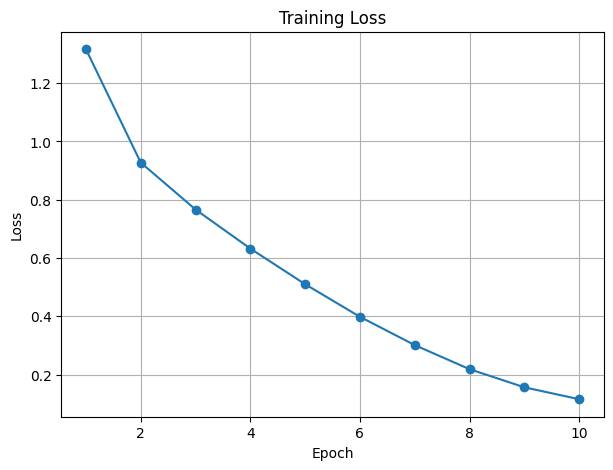

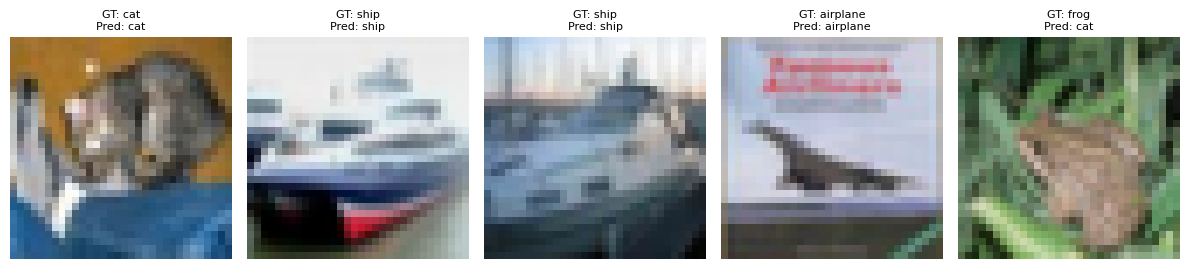

In [10]:


import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = (
    'airplane','automobile','bird','cat',
    'deer','dog','frog','horse',
    'ship','truck'
)



class MyCNN(nn.Module):

    def __init__(self):
        super(MyCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.fc1 = nn.Linear(
            64 * 8 * 8,
            256
        )

        self.fc2 = nn.Linear(
            256,
            10
        )

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))

        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x


model = MyCNN().to(device)



criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

loss_history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(trainloader)

    epoch_accuracy = 100 * correct / total

    loss_history.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Training Loss : {epoch_loss:.4f}")
    print(f"Training Accuracy : {epoch_accuracy:.2f}%")
    print("-"*40)



model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"\nTest Accuracy = {test_accuracy:.2f}%")



plt.figure(figsize=(7,5))

plt.plot(range(1,epochs+1), loss_history, marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()



images, labels = next(iter(testloader))

images = images[:5]
labels = labels[:5]

outputs = model(images.to(device))

_, predicted = torch.max(outputs,1)

images = images * 0.5 + 0.5

fig = plt.figure(figsize=(12,3))

for i in range(5):

    ax = fig.add_subplot(1,5,i+1)

    img = images[i].permute(1,2,0)

    ax.imshow(img)

    ax.set_title(
        f"GT: {classes[labels[i]]}\nPred: {classes[predicted[i]]}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

plt.show()